### Análise de robustez: efeito de incluir os casos INAPTA como fracasso

**Entrada:** `data/dataset_excluidos_robustez.parquet` (12.822 linhas, casos com situação INAPTA excluídos do alvo original), `data/modelo_final_logit.pickle` e `data/df_modelo_treino.parquet` (notebook 05).

**Objetivo:** testar se o modelo final muda muito (AUC/GINI) quando os casos INAPTA -- hoje fora do alvo -- entram no treino como fracasso (`alvo=1`), como checagem de robustez da decisão de excluí-los.

#### 1. Carregamento e preparação dos preditores (INAPTA)

Carrega o dataset dos casos INAPTA e recria os mesmos preditores dos notebooks 01-04 (idade, log do capital, agrupamentos de natureza jurídica, região e CNAE), para poder pontuá-los com o modelo já treinado.

In [1]:
# mesmas bibliotecas do notebook 05: statsmodels para carregar/reestimar o modelo, sklearn só para AUC
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [2]:
# casos com situacao INAPTA, deixados fora do alvo original -- aqui serao pontuados pelo modelo treinado
df_robustez = pd.read_parquet('../data/dataset_excluidos_robustez.parquet')
print(df_robustez.shape)

(12822, 43)


In [3]:
# idade_empresa_anos (mesma referência: 08/08/2026)
df_robustez['data_inicio_atividade'] = pd.to_datetime(df_robustez['data_inicio_atividade'], errors='coerce')
df_robustez['idade_empresa_anos'] = (
    pd.Timestamp('2026-08-08') - df_robustez['data_inicio_atividade']
).dt.days / 365.25

In [4]:
# capital_social_log -- mesma transformacao (log1p) do notebook 05
df_robustez['capital_social_log'] = np.log1p(df_robustez['capital_social'])

In [5]:
# natureza_juridica_agrupada -- regra exata do notebook 03
CODIGOS_OUTRAS = ["2143", "2240", "3999", "2216", "2038", "2127"]
df_robustez['natureza_juridica'] = df_robustez['natureza_juridica'].astype(str)
df_robustez['natureza_juridica_agrupada'] = df_robustez['natureza_juridica'].where(
    ~df_robustez['natureza_juridica'].isin(CODIGOS_OUTRAS), 'Outras'
)

In [6]:
# regiao -- mesmo mapa do notebook 04
MAPA_REGIAO = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MS": "Centro-Oeste", "MT": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}
df_robustez['uf'] = df_robustez['uf'].astype(str)
df_robustez['regiao'] = df_robustez['uf'].map(MAPA_REGIAO)

In [7]:
# grupo_cnae -- 3 primeiros dígitos do CNAE
df_robustez['cnae_fiscal_principal'] = df_robustez['cnae_fiscal_principal'].astype(str)
df_robustez['grupo_cnae'] = df_robustez['cnae_fiscal_principal'].str[:3]

In [8]:
# identificador_matriz_filial e porte_empresa como string, igual ao treino
df_robustez['identificador_matriz_filial'] = df_robustez['identificador_matriz_filial'].astype(str)
df_robustez['porte_empresa'] = df_robustez['porte_empresa'].astype(str)

#### 2. Checagem de consistência de categorias

Confere nulos e categorias inesperadas nos preditores recriados, para garantir que o modelo treinado sabe lidar com todo valor que aparece aqui.

In [9]:
# --- Checagem antes de seguir: apareceu categoria que o modelo nunca viu no treino? ---
print("Nulos por coluna-chave:")
print(df_robustez[['idade_empresa_anos', 'capital_social_log', 'natureza_juridica_agrupada',
                    'regiao', 'grupo_cnae', 'identificador_matriz_filial', 'porte_empresa']].isna().sum())

esperado_natureza = {'2135', '2062', '2054', '2046', 'Outras'}
esperado_cnae = {'471', '472', '473', '474', '475', '476', '477', '478'}
esperado_porte = {'01', '03', '05'}
esperado_matriz = {'1', '2'}

print("\nCategorias inesperadas em natureza_juridica_agrupada:",
      set(df_robustez['natureza_juridica_agrupada'].unique()) - esperado_natureza)
print("Categorias inesperadas em grupo_cnae:",
      set(df_robustez['grupo_cnae'].unique()) - esperado_cnae)
print("Categorias inesperadas em porte_empresa:",
      set(df_robustez['porte_empresa'].unique()) - esperado_porte)
print("Categorias inesperadas em identificador_matriz_filial:",
      set(df_robustez['identificador_matriz_filial'].unique()) - esperado_matriz)

Nulos por coluna-chave:
idade_empresa_anos             0
capital_social_log             0
natureza_juridica_agrupada     0
regiao                         0
grupo_cnae                     0
identificador_matriz_filial    0
porte_empresa                  0
dtype: int64

Categorias inesperadas em natureza_juridica_agrupada: set()
Categorias inesperadas em grupo_cnae: set()
Categorias inesperadas em porte_empresa: set()
Categorias inesperadas em identificador_matriz_filial: set()


#### 3. Codificação categórica

Aplica a mesma codificação em dummies do notebook 05 (mesma ordem de categorias, mesma categoria de referência), para o dataset ficar no formato que o modelo espera.

In [10]:
# mesma ordem de categorias (referência = mais frequente) e o mesmo drop_first do notebook 05,
# senao os nomes das colunas dummy nao batem com os que o modelo espera
ordem_categorias = {
    'identificador_matriz_filial': ['1', '2'],
    'porte_empresa': ['01', '03', '05'],
    'natureza_juridica_agrupada': ['2135', '2062', '2054', '2046', 'Outras'],
    'regiao': ['Sudeste', 'Nordeste', 'Sul', 'Centro-Oeste', 'Norte'],
    'grupo_cnae': ['478', '472', '475', '471', '477', '474', '476', '473'],
}

for col, ordem in ordem_categorias.items():
    df_robustez[col] = pd.Categorical(df_robustez[col], categories=ordem, ordered=False)

df_robustez_dummies = pd.get_dummies(
    df_robustez,
    columns=list(ordem_categorias.keys()),
    drop_first=True,
    dtype=int,
)

df_robustez_dummies.columns = df_robustez_dummies.columns.str.replace('-', '_', regex=False)


#### 4. Carregamento do modelo treinado

Localiza e carrega o modelo ajustado no notebook 05 -- a checagem de caminho existe porque este notebook roda com cwd relativo à pasta `notebooks/`.

In [11]:
# checagem pontual de caminho -- feita uma vez para confirmar qual caminho relativo funciona antes de carregar o modelo
import os
print("cwd atual (notebook 06):", os.getcwd())

for caminho in ['data/modelo_final_logit.pickle', '../data/modelo_final_logit.pickle', 'modelo_final_logit.pickle']:
    print(caminho, "-> existe?", os.path.exists(caminho))

cwd atual (notebook 06): /home/barbara/projetos_linux/sl-varejo-log/notebooks
data/modelo_final_logit.pickle -> existe? False
../data/modelo_final_logit.pickle -> existe? True
modelo_final_logit.pickle -> existe? False


In [12]:
# carrega o modelo final (Stepwise, 18 preditores) ajustado no notebook 05
modelo_step = sm.load('../data/modelo_final_logit.pickle')
print(modelo_step.summary())

                           Logit Regression Results                           
Dep. Variable:                   alvo   No. Observations:                45874
Model:                          Logit   Df Residuals:                    45855
Method:                           MLE   Df Model:                           18
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                 0.06244
Time:                        16:09:10   Log-Likelihood:                -29107.
converged:                       True   LL-Null:                       -31046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.2327      0.103     -2.259      0.024      -0.435      -0.031
idade_empresa_anos                    0.1867      0.012     16

#### 5. Verificação de compatibilidade de colunas

Confere, nos dois sentidos, que todo preditor esperado pelo modelo existe no dataset de robustez codificado, antes de gerar previsões.

In [13]:
# confere se todas as colunas que o modelo final espera existem aqui (faltando = quebraria o predict)
preditores_modelo = [c for c in modelo_step.params.index if c != 'Intercept']
faltando = [c for c in preditores_modelo if c not in df_robustez_dummies.columns]
print("Colunas esperadas pelo modelo que faltam no df_robustez_dummies:", faltando)

Colunas esperadas pelo modelo que faltam no df_robustez_dummies: []


In [14]:
# repete o carregamento do modelo e amplia a checagem da célula anterior para os dois sentidos
# (faltando e sobrando) -- redundante com a célula acima, mantido como verificação extra antes de prever
modelo_step = sm.load('../data/modelo_final_logit.pickle')
preditores_modelo = set(modelo_step.params.index) - {"Intercept"}
colunas_robustez = set(df_robustez_dummies.columns)

faltando = preditores_modelo - colunas_robustez
sobrando = colunas_robustez - preditores_modelo

print("Preditores que o modelo espera e NÃO estão em df_robustez_dummies:")
print(faltando if faltando else "Nenhum — ok")

print("\nColunas em df_robustez_dummies que o modelo NÃO usa (esperado ter algumas, ok):")
print(sobrando)

Preditores que o modelo espera e NÃO estão em df_robustez_dummies:
Nenhum — ok

Colunas em df_robustez_dummies que o modelo NÃO usa (esperado ter algumas, ok):
{'capital_social', 'optante_mei', 'nome_cidade_exterior', 'logradouro', 'situacao_especial', 'razao_social', 'motivo_situacao_cadastral', 'optante_simples', 'telefone2', 'data_opcao_mei', 'natureza_juridica', 'pais', 'complemento', 'municipio', 'data_inicio_atividade', 'cnae_fiscal_principal', 'cnpj_dv', 'cep', 'nome_fantasia', 'bairro', 'telefone1', 'risco', 'cnpj_basico', 'data_exclusao_simples', 'regiao_Sul', 'cnae_fiscal_secundaria', 'tipo_logradouro', 'ddd2', 'ddd_fax', 'fax', 'data_situacao_especial', 'data_opcao_simples', 'correio_eletronico', 'regiao_Norte', 'uf', 'qualificacao_responsavel', 'ddd1', 'numero', 'data_situacao_cadastral', 'ente_federativo_responsavel', 'data_exclusao_mei', 'situacao_cadastral', 'cnpj_ordem'}


#### 6. Previsão de probabilidade para os casos INAPTA

Usa o modelo treinado para prever a probabilidade de baixada de cada caso INAPTA, sem re-treinar nada.

In [15]:
# aplica o modelo treinado (sem re-treinar) aos casos INAPTA para obter a probabilidade prevista de baixada
df_robustez["prob_baixada_prevista"] = modelo_step.predict(df_robustez_dummies)

print(df_robustez["prob_baixada_prevista"].describe())

count    12822.000000
mean         0.606765
std          0.126959
min          0.100149
25%          0.586070
50%          0.638480
75%          0.681734
max          0.938351
Name: prob_baixada_prevista, dtype: float64


#### 7. Comparação visual das distribuições

Compara a probabilidade prevista entre ATIVA, INAPTA e BAIXADA num boxplot -- se INAPTA ficar entre as outras duas, é sinal de que o modelo já capta esses casos como intermediários, mesmo sem tê-los visto no treino.

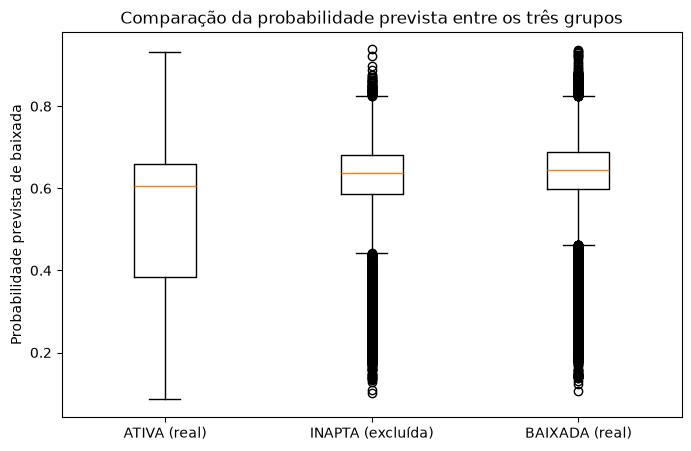

In [16]:
# compara a probabilidade prevista nos 3 grupos: os dois extremos reais (ATIVA/BAIXADA) do treino
# e o grupo INAPTA (nunca visto no treino), para checar se ele cai entre os dois como esperado

df_probs_treino = pd.read_parquet("../data/probs_treino.parquet")

grupo_ativa = df_probs_treino.loc[df_probs_treino["alvo"] == 0, "prob_baixada_prevista"]
grupo_baixada = df_probs_treino.loc[df_probs_treino["alvo"] == 1, "prob_baixada_prevista"]
grupo_inapta = df_robustez["prob_baixada_prevista"]

plt.figure(figsize=(8, 5))
plt.boxplot(
    [grupo_ativa, grupo_inapta, grupo_baixada],
    tick_labels=["ATIVA (real)", "INAPTA (excluída)", "BAIXADA (real)"]
)
plt.ylabel("Probabilidade prevista de baixada")
plt.title("Comparação da probabilidade prevista entre os três grupos")
plt.savefig("../outputs/robustez_boxplot_inapta.png", dpi=150, bbox_inches="tight")
plt.show()

#### 8. Preparação do dataset combinado (treino + INAPTA)

Confere que os preditores necessários existem, junta o treino original com os casos INAPTA relabelados como `alvo=1` e confere se alguma categoria nova apareceu na base combinada.

In [17]:
# checagem final de que os preditores usados no modelo existem em df_robustez antes de combinar os datasets
colunas_necessarias = ['identificador_matriz_filial', 'idade_empresa_anos', 'porte_empresa',
                        'natureza_juridica_agrupada', 'regiao', 'grupo_cnae', 'capital_social_log']

faltando = [c for c in colunas_necessarias if c not in df_robustez.columns]
print("Faltando em df_robustez:", faltando if faltando else "Nenhuma — ok")

Faltando em df_robustez: Nenhuma — ok


In [18]:
# junta o treino original com os casos INAPTA relabelados como fracasso (alvo=1) -- cenario mais
# pessimista possivel, so para testar se a discriminacao do modelo (AUC/GINI) muda muito caso essa
# hipotese fosse verdadeira; nao e uma afirmacao de que INAPTA equivale a fracasso de fato
df_treino_original = pd.read_parquet("../data/df_modelo_treino.parquet")

colunas_predictoras = ['identificador_matriz_filial', 'idade_empresa_anos', 'porte_empresa',
                        'natureza_juridica_agrupada', 'regiao', 'grupo_cnae', 'capital_social_log']

df_robustez_relabel = df_robustez[colunas_predictoras].copy()
df_robustez_relabel["alvo"] = 1

df_combinado = pd.concat([df_treino_original, df_robustez_relabel], ignore_index=True)

print("Shape combinado:", df_combinado.shape)
print(df_combinado["alvo"].value_counts())

Shape combinado: (58696, 8)
alvo
1    39900
0    18796
Name: count, dtype: int64


In [19]:
# confere se o dataset combinado ainda respeita as categorias esperadas por cada preditor
ordem_categorias = {
    'identificador_matriz_filial': ['1', '2'],
    'porte_empresa': ['01', '03', '05'],
    'natureza_juridica_agrupada': ['2135', '2062', '2054', '2046', 'Outras'],
    'regiao': ['Sudeste', 'Nordeste', 'Sul', 'Centro-Oeste', 'Norte'],
    'grupo_cnae': ['478', '472', '475', '471', '477', '474', '476', '473'],
}

for col, ordem in ordem_categorias.items():
    inesperadas = set(df_combinado[col].unique()) - set(ordem)
    print(f"{col}: categorias inesperadas = {inesperadas if inesperadas else 'nenhuma'}")

identificador_matriz_filial: categorias inesperadas = nenhuma
porte_empresa: categorias inesperadas = nenhuma
natureza_juridica_agrupada: categorias inesperadas = nenhuma
regiao: categorias inesperadas = nenhuma
grupo_cnae: categorias inesperadas = nenhuma


#### 9. Reestimação do modelo com INAPTA incluído

Recodifica o dataset combinado em dummies e ajusta a mesma fórmula do modelo original, como primeiro ponto de comparação antes do stepwise.

In [20]:
# mesma codificação em dummies de sempre, agora no dataset combinado (treino + INAPTA)
for col, ordem in ordem_categorias.items():
    df_combinado[col] = pd.Categorical(df_combinado[col], categories=ordem, ordered=False)

df_combinado_dummies = pd.get_dummies(
    df_combinado,
    columns=list(ordem_categorias.keys()),
    drop_first=True,
    dtype=int,
)

df_combinado_dummies.columns = df_combinado_dummies.columns.str.replace('-', '_', regex=False)

print(df_combinado_dummies.shape)

import statsmodels.formula.api as smf

# reusa a mesma fórmula (mesmos preditores) do modelo final do notebook 05, só muda o dataset
formula_usada = modelo_step.model.formula
print("\nFórmula usada:", formula_usada)

modelo_robustez = smf.logit(formula_usada, data=df_combinado_dummies).fit()
print(modelo_robustez.summary())

(58696, 21)

Fórmula usada: alvo ~ idade_empresa_anos + capital_social_log + identificador_matriz_filial_2 + porte_empresa_03 + porte_empresa_05 + natureza_juridica_agrupada_2062 + natureza_juridica_agrupada_2054 + natureza_juridica_agrupada_2046 + natureza_juridica_agrupada_Outras + regiao_Nordeste + regiao_Centro_Oeste + grupo_cnae_472 + grupo_cnae_475 + grupo_cnae_471 + grupo_cnae_477 + grupo_cnae_474 + grupo_cnae_476 + grupo_cnae_473


Optimization terminated successfully.
         Current function value: 0.593526
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   alvo   No. Observations:                58696
Model:                          Logit   Df Residuals:                    58677
Method:                           MLE   Df Model:                           18
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                 0.05345
Time:                        16:09:13   Log-Likelihood:                -34838.
converged:                       True   LL-Null:                       -36805.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0326      0.095      0

#### 10. Seleção de variáveis no dataset combinado (stepwise)

Reaplica o mesmo stepwise manual do notebook 05, agora no dataset combinado, para chegar à especificação final do modelo de robustez.

In [21]:
# mesmo stepwise manual do notebook 05 (redefinido aqui, sem import compartilhado), agora aplicado
# ao dataset combinado (treino + INAPTA como fracasso)
def stepwise_manual(formula_base, data, pvalue_limit=0.05, verbose=True):
    formula_atual = formula_base
    while True:
        modelo = sm.Logit.from_formula(formula_atual, data=data).fit(disp=0)
        pvalues = modelo.pvalues.drop('Intercept')
        pior_pvalue = pvalues.max()

        if pior_pvalue <= pvalue_limit:
            break

        variavel_remover = pvalues.idxmax()
        if verbose:
            print(f"Removendo '{variavel_remover}' (p-valor = {pior_pvalue:.4f})")

        preditores_restantes = [v for v in pvalues.index if v != variavel_remover]
        formula_atual = 'alvo ~ ' + ' + '.join(preditores_restantes)

    return modelo, formula_atual


preditores_completos = [c for c in df_combinado_dummies.columns if c != "alvo"]
formula_completa_robustez = "alvo ~ " + " + ".join(preditores_completos)
print("Fórmula completa (antes do Stepwise):")
print(formula_completa_robustez)

modelo_robustez_step, formula_final_robustez = stepwise_manual(
    formula_completa_robustez, df_combinado_dummies, pvalue_limit=0.05
)

print("\n" + "="*70)
print("Fórmula final após o Stepwise (dataset com INAPTA=1):")
print(formula_final_robustez)
print("="*70 + "\n")
print(modelo_robustez_step.summary())

Fórmula completa (antes do Stepwise):
alvo ~ idade_empresa_anos + capital_social_log + identificador_matriz_filial_2 + porte_empresa_03 + porte_empresa_05 + natureza_juridica_agrupada_2062 + natureza_juridica_agrupada_2054 + natureza_juridica_agrupada_2046 + natureza_juridica_agrupada_Outras + regiao_Nordeste + regiao_Sul + regiao_Centro_Oeste + regiao_Norte + grupo_cnae_472 + grupo_cnae_475 + grupo_cnae_471 + grupo_cnae_477 + grupo_cnae_474 + grupo_cnae_476 + grupo_cnae_473


Removendo 'regiao_Norte' (p-valor = 0.1949)



Fórmula final após o Stepwise (dataset com INAPTA=1):
alvo ~ idade_empresa_anos + capital_social_log + identificador_matriz_filial_2 + porte_empresa_03 + porte_empresa_05 + natureza_juridica_agrupada_2062 + natureza_juridica_agrupada_2054 + natureza_juridica_agrupada_2046 + natureza_juridica_agrupada_Outras + regiao_Nordeste + regiao_Sul + regiao_Centro_Oeste + grupo_cnae_472 + grupo_cnae_475 + grupo_cnae_471 + grupo_cnae_477 + grupo_cnae_474 + grupo_cnae_476 + grupo_cnae_473

                           Logit Regression Results                           
Dep. Variable:                   alvo   No. Observations:                58696
Model:                          Logit   Df Residuals:                    58676
Method:                           MLE   Df Model:                           19
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                 0.05351
Time:                        16:09:15   Log-Likelihood:                -34835.
converged:                       True   LL-

#### 11. Comparação de AUC/GINI: robustez vs. original

Compara a AUC/GINI do modelo de robustez com os valores originais do notebook 05: se a queda for pequena, a decisão de excluir os INAPTA não muda a conclusão do modelo.

In [22]:
# AUC/GINI original (0.6521 / 0.3042) são os valores já obtidos no notebook 05, copiados aqui como
# referência fixa de comparação -- não recalculados neste notebook
probs_robustez_step = modelo_robustez_step.predict(df_combinado_dummies)
auc_robustez_step = roc_auc_score(df_combinado_dummies["alvo"], probs_robustez_step)
gini_robustez_step = 2 * auc_robustez_step - 1

print(f"AUC (com INAPTA=1, Stepwise próprio):  {auc_robustez_step:.4f}")
print(f"GINI (com INAPTA=1, Stepwise próprio): {gini_robustez_step:.4f}")

print(f"\nAUC (original, sem INAPTA):  0.6521")
print(f"GINI (original, sem INAPTA): 0.3042")
print(f"\nDiferença de AUC: {auc_robustez_step - 0.6521:+.4f}")

AUC (com INAPTA=1, Stepwise próprio):  0.6415
GINI (com INAPTA=1, Stepwise próprio): 0.2829

AUC (original, sem INAPTA):  0.6521
GINI (original, sem INAPTA): 0.3042

Diferença de AUC: -0.0106
